In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test and test sets from SDF files
test_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Machine Learning (Done)\Inhalation\Dataset\test_set_acute_inhalation_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())

------test DataFrame UnCalculate------
     id     casrn smiles (First)   Molecular weight                name  \
0  2564   64-19-7                 60.05195999145508         acetic acid   
1  1454  110-76-9                 90.14418029785156  2-ethoxyethanamine   

  Outcome         Molecule (RDKit Mol) (InChI Code) reference molecule_form  \
0       1     InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)      ECHA             V   
1       0  InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3      ECHA             V   

  ID RowID                                 Morgan_Descriptors  \
0      282  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1      183  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   SMILES  
0  [-0.9933128039738658, -1.3775249672735086, -1....  CC(=O)O  
1  [

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update test_df dengan kolom baru
for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())

Check Keys
Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor',
       'SMILES', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2', 'MLogP', 'TPSA',
       'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc',
       'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings',
       'NumAromaticHeterocycles', 'NumSaturatedHeterocycles',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v',
       'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi

In [4]:
test_df.keys()

Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor',
       'SMILES', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2', 'MLogP', 'TPSA',
       'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA', 'nHBAcc',
       'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'naAromAtom', 'NumSaturatedRings', 'NumAliphaticRings',
       'NumAromaticHeterocycles', 'NumSaturatedHeterocycles',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v',
       'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n

In [5]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP
46,3479,124-10-7,,242.403,methyl tetradecanoate,0,InChI=1S/C15H30O2/c1-3-4-5-6-7-8-9-10-11-12-13...,ECHA,A,,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6077057507230454, -0.33602925539040474, -0....",CCCCCCCCCCCCCC(=O)OC,0,2,17.0,0.5,12,0.0,26.30,2.961268,4.86050,0.933333,242.403,242.403,4.86050,4.86050,23.624460,4.86050,26.30,73.0940,107.123508,2,2,2,0,0,12,0,2,17,0,0,0,0,0,0,0,0,0,0,0,11.801778,7.377157,4.861667,3.212125,2.035613,7.377157,4.861667,3.212125,2.035613,-0.530000,16.470000,13.534641,13.405667,0.933333,212.163,12,0.0,0.0,17.0
64,293; 261; 390,17865-32-6,,188.343,-,0,InChI=1S/C9H20O2Si/c1-10-12(11-2)8-9-6-4-3-5-7...,ECHA,A,,64,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.1123415213373063, 0.3254697869479871, 0.373...",CO[SiH](CC1CCCCC1)OC,0,2,12.0,0.5,4,0.0,18.46,2.179611,2.08000,1.000000,188.343,188.343,2.08000,2.08000,4.326400,2.08000,18.46,52.5490,77.104366,2,2,2,0,0,4,0,3,12,1,0,0,1,1,0,0,0,0,1,1,9.368538,6.680200,5.914031,4.879445,3.576768,4.920894,3.640701,2.776312,1.983683,0.136883,10.219277,5.726183,3.249835,1.000000,168.183,4,0.0,0.0,12.0
63,314607,75-12-7,NC=O,45.041,Formamide,0,"InChI=1S/CH3NO/c2-1-3/h1H,(H2,2,3)",ToxValDB,not specified,,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5...",NC=O,1,1,3.0,0.5,0,0.0,43.09,2.187496,-0.89850,0.000000,45.041,45.041,-0.89850,-0.89850,0.807302,-0.89850,43.09,10.2514,18.240664,1,1,1,1,1,0,1,2,3,0,0,0,0,0,0,0,0,0,0,0,1.562949,0.569036,0.136083,0.000000,0.000000,0.569036,0.136083,0.000000,0.000000,-0.530000,2.470000,1.470000,1.470000,0.000000,42.017,0,0.0,0.0,3.0
102,1813,56706-10-6,,474.834,"4,4,13,13-tetraethoxy-3,14-dioxa-8,9-dithia-4,...",0,"InChI=1S/C18H42O6S2Si2/c1-7-19-27(20-8-2,21-9-...",ECHA,A,,102,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1.7776289960049216, 0.6764532334438542, 0.731...",CCO[Si](CCCSSCCC[Si](OCC)(OCC)OCC)(OCC)OCC,0,8,28.0,0.5,21,0.0,55.38,4.137941,5.24480,1.000000,474.834,474.834,5.24480,5.24480,27.507927,5.24480,55.38,125.0280,182.772666,8,8,8,0,0,21,0,10,28,0,0,0,0,0,0,0,0,0,0,0,22.384261,17.002297,13.981375,12.570317,10.726872,10.650560,5.815159,3.690106,2.815544,0.893766,28.893766,18.645894,12.557597,1.000000,432.498,21,0.0,0.0,28.0
61,2898,93777-46-9,,284.484,decyl 2-ethylhexanoate,0,InChI=1S/C18H36O2/c1-4-7-9-10-11-12-13-14-16-2...,ECHA,A,,61,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9350817923709542, 0.2348370861375396, 0.280...",CCCCCCCCCCOC(=O)C(CC)CCCC,0,2,20.0,0.5,14,0.0,26.30,3.414231,5.88670,0.944444,284.484,284.484,5.88670,5.88670,34.653237,5.88670,26.30,86.8750,126.218334,2,2,2,0,0,14,0,2,20,0,0,0,0,0,0,0,0,0,0,0,14.086235,8.923415,5.889771,3.974484,2.465723,8.923415,5.889771,3.974484,2.465723,-0.530000,19.470000,14.870337,11.309526,0.944444,248.196,14,0.0,0.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Classes                          :  ['0' '1']
Number of cpds in each class     :  [59 77]
Total number of cpds             :  136


{'0': 0, '1': 1}

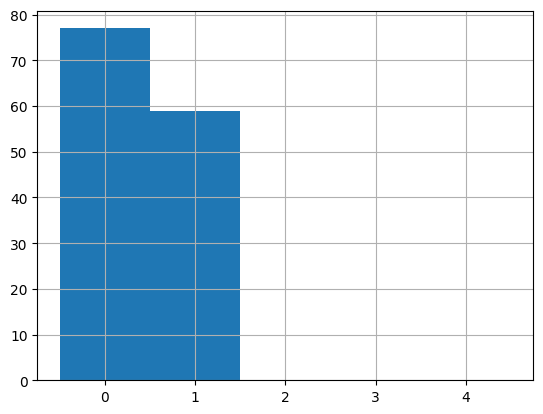

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
# menghitung semua deskriptor fisikokimia RDKit
def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
    descriptor_funcs = Descriptors.descList
    return {name: func(mol) for name, func in descriptor_funcs}

desc_df = test_df['SMILES'].apply(compute_rdkit_descriptors).apply(pd.Series)

test_df = pd.concat([test_df, desc_df], axis=1)

# cek hasil
print(test_df.shape)
print(test_df.columns)


(136, 290)
Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=290)


In [9]:
x_rdkitcdk = test_df.drop(columns=['RowID','id', 'casrn', 'smiles (First)','Molecular weight','name','Outcome','Molecule (RDKit Mol) (InChI Code)','reference', 'molecule_form', 'ID',
       'SMILES','Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor','Molecular Weight', 'logP'])

In [10]:
x_rdkitcdk.shape

(136, 273)

In [11]:
x = x_rdkitcdk

In [ ]:
#default start

In [ ]:
x_rdkitcdk = test_df.drop(columns=['RowID','id', 'casrn', 'smiles (First)','Molecular weight','name','Outcome','Molecule (RDKit Mol) (InChI Code)','reference', 'molecule_form', 'ID',
       'SMILES','Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor','Molecular Weight', 'logP'])

In [ ]:
x_rdkitcdk.shape

In [ ]:
x = x_rdkitcdk

In [ ]:
#default end

In [12]:
test_df

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAmideBonds,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumAtomStereoCenters,NumBridgeheadAtoms,NumHAcceptors,NumHDonors,NumHeteroatoms,NumHeterocycles,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
46,3479,124-10-7,,242.403,methyl tetradecanoate,0,InChI=1S/C15H30O2/c1-3-4-5-6-7-8-9-10-11-12-13...,ECHA,A,,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6077057507230454, -0.33602925539040474, -0....",CCCCCCCCCCCCCC(=O)OC,0,2,17.0,0.5,12,0.0,26.30,2.961268,4.86050,0.933333,242.403,242.403,4.86050,4.86050,23.624460,4.86050,26.30,73.0940,107.123508,2,2,2,0,0,12,0,2,17,0,0,0,0,0,0,0,0,0,0,0,11.801778,7.377157,4.861667,3.212125,2.035613,7.377157,4.861667,3.212125,2.035613,-0.530000,16.470000,13.534641,13.405667,0.933333,212.163,12,0.0,0.0,1

In [13]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

                id       casrn smiles (First)  Molecular weight  \
46            3479    124-10-7                          242.403   
64   293; 261; 390  17865-32-6                          188.343   
63          314607     75-12-7           NC=O            45.041   
102           1813  56706-10-6                          474.834   
61            2898  93777-46-9                          284.484   
..             ...         ...            ...               ...   
45            3215     64-18-6                           46.025   
43          201472    106-50-3   Nc1ccc(N)cc1           108.144   
41            1491   1609-86-5                           99.133   
55            1738   3068-39-1                          429.540   
135         802256   2231-57-4      NNC(=S)NN           106.154   

                                                  name Outcome  \
46                               methyl tetradecanoate       0   
64                                                   -       0 

In [14]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [15]:
x_test_rdkit_cdk

array([[ 0.,  2., 17., ...,  0., 10.,  0.],
       [ 0.,  2., 12., ...,  0.,  0.,  0.],
       [ 1.,  1.,  3., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  2.,  7., ...,  0.,  0.,  0.],
       [ 2.,  4., 32., ...,  0.,  0.,  0.],
       [ 4.,  3.,  6., ...,  0.,  0.,  0.]])

In [16]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [17]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [18]:
import joblib
from pathlib import Path

# Path dasar
desc_path = Path(r"D:\Riset QSAR - TTX\Machine Learning (Done)\Inhalation\Model\Descriptor")
phys_path = Path(r"D:\Riset QSAR - TTX\Machine Learning (Done)\Inhalation\Model\Physiochemical")

# ----------- DESKRIPTOR -----------
rf_morgan   = joblib.load(desc_path / "Model_inhalation_toxicity_RF_morgan.pkl")
rf_maccskey = joblib.load(desc_path / "Model_inhalation_toxicity_RF_maccskey.pkl")
rf_modred   = joblib.load(desc_path / "Model_inhalation_toxicity_RF_modred.pkl")

svm_morgan   = joblib.load(desc_path / "Model_inhalation_toxicity_SVM_morgan.pkl")
svm_maccskey = joblib.load(desc_path / "Model_inhalation_toxicity_SVM_maccskey.pkl")
svm_modred   = joblib.load(desc_path / "Model_inhalation_toxicity_SVM_modred.pkl")

xgb_morgan   = joblib.load(desc_path / "Model_inhalation_toxicity_XGB_morgan.pkl")
xgb_maccskey = joblib.load(desc_path / "Model_inhalation_toxicity_XGB_maccskey.pkl")
xgb_modred   = joblib.load(desc_path / "Model_inhalation_toxicity_XGB_modred.pkl")

nn_morgan   = joblib.load(desc_path / "Model_inhalation_toxicity_NN_morgan.pkl")
nn_maccskey = joblib.load(desc_path / "Model_inhalation_toxicity_NN_maccskey.pkl")
nn_modred   = joblib.load(desc_path / "Model_inhalation_toxicity_NN_modred.pkl")

lgbm_morgan   = joblib.load(desc_path / "Model_inhalation_toxicity_LGBM_morgan.pkl")
lgbm_maccskey = joblib.load(desc_path / "Model_inhalation_toxicity_LGBM_maccskey.pkl")
lgbm_modred   = joblib.load(desc_path / "Model_inhalation_toxicity_LGBM_modred.pkl")

# ----------- FISIOKIMIA -----------
rf_p   = joblib.load(phys_path / "Model_inhalation_toxicity_RF_rdkit_cdk.pkl")
svm_p  = joblib.load(phys_path / "Model_inhalation_toxicity_SVM_rdkit_cdk.pkl")
xgb_p  = joblib.load(phys_path / "Model_inhalation_toxicity_XGB_rdkit_cdk.pkl")
nn_p   = joblib.load(phys_path / "Model_inhalation_toxicity_NN_rdkit_cdk.pkl")
lgbm_p = joblib.load(phys_path / "Model_inhalation_toxicity_LGBM_rdkit_cdk.pkl")


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  



In [20]:
#scaler dasta
import numpy as np
import joblib

try:
    scaler = joblib.load('train_scaler.pkl')
except FileNotFoundError:
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    x_temp = np.array(test_df['rdkit_cdk'].tolist())
    scaler.fit(x_temp)

# define x_test
x_test_raw = np.array(test_df['rdkit_cdk'].tolist())

x_test = scaler.transform(x_test_raw)

print(f"Shape x_test Sekarang: {x_test.shape}") 
# feature used (136, 56)

print(x_test[:5])

Shape x_test Sekarang: (136, 273)
[[-0.53041641 -0.05172994  0.48061538 ...  0.          2.8660757
  -0.0860663 ]
 [-0.53041641 -0.05172994 -0.05603234 ...  0.         -0.35529864
  -0.0860663 ]
 [ 0.38270551 -0.5542494  -1.02199823 ...  0.         -0.35529864
  -0.0860663 ]
 [-0.53041641  2.96338679  1.66124036 ...  0.         -0.35529864
  -0.0860663 ]
 [-0.53041641 -0.05172994  0.80260401 ...  0.          2.22180083
  -0.0860663 ]]


In [21]:
x_test

test_df

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAmideBonds,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumAtomStereoCenters,NumBridgeheadAtoms,NumHAcceptors,NumHDonors,NumHeteroatoms,NumHeterocycles,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,rdkit_cdk
46,3479,124-10-7,,242.403,methyl tetradecanoate,0,InChI=1S/C15H30O2/c1-3-4-5-6-7-8-9-10-11-12-13...,ECHA,A,,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6077057507230454, -0.33602925539040474, -0....",CCCCCCCCCCCCCC(=O)OC,0,2,17.0,0.5,12,0.0,26.30,2.961268,4.86050,0.933333,242.403,242.403,4.86050,4.86050,23.624460,4.86050,26.30,73.0940,107.123508,2,2,2,0,0,12,0,2,17,0,0,0,0,0,0,0,0,0,0,0,11.801778,7.377157,4.861667,3.212125,2.035613,7.377157,4.861667,3.212125,2.035613,-0.530000,16.470000,13.534641,13.405667,0.933333,212.163,12

In [22]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# Run prediction
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# Evaluate performance
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[54 23]
 [33 26]]
Accuracy: 0.5882352941176471
AUC Score: 0.6213955535989434
F1 Score: 0.48148148148148145
Sensitivity: 0.4406779661016949
Specificity: 0.7012987012987013
CCR (Correct Classification Rate): 0.5709883337001981
PPV (Positive Predictive Value): 0.5306122448979592
NPV (Negative Predictive Value): 0.6206896551724138


In [ ]:
#individual descriptor

In [24]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccskey, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan":   rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": rf_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   rf_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccskey,
    rf_modred
)

for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[ 6 71]
 [ 1 58]]
Accuracy: 0.47058823529411764
AUC: 0.5843055249834911
F1 Score: 0.6170212765957447
Sensitivity: 0.9830508474576272
Specificity: 0.07792207792207792
CCR: 0.5304864626898526
PPV (Precision): 0.4496124031007752
NPV: 0.8571428571428571

MACCSkey RF Performance
Confusion Matrix: [[54 23]
 [11 48]]
Accuracy: 0.75
AUC: 0.7981510015408321
F1 Score: 0.7384615384615385
Sensitivity: 0.8135593220338984
Specificity: 0.7012987012987013
CCR: 0.7574290116662998
PPV (Precision): 0.676056338028169
NPV: 0.8307692307692308

Modred RF Performance
Confusion Matrix: [[59 18]
 [16 43]]
Accuracy: 0.75
AUC: 0.7891261281091789
F1 Score: 0.7166666666666667
Sensitivity: 0.7288135593220338
Specificity: 0.7662337662337663
CCR: 0.7475236627779
PPV (Precision): 0.7049180327868853
NPV: 0.7866666666666666

CONSENSUS RF (Morgan + MACCSkey + Modred)
Confusion Matrix: [[54 23]
 [13 46]]
Accuracy: 0.7352941176470589
AUC: 0.8080563504292319
F1 Score: 0.71875
Sensiti

In [25]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccskey, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan":   svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": svm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccskey,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[11 66]
 [ 5 54]]
Accuracy: 0.47794117647058826
AUC: 0.5865067136253577
F1 Score: 0.6033519553072626
Sensitivity (Recall+): 0.9152542372881356
Specificity (Recall-): 0.14285714285714285
CCR: 0.5290556900726392
PPV (Precision): 0.45
NPV: 0.6875

MACCSkey SVM Performance
Confusion Matrix: [[54 23]
 [11 48]]
Accuracy: 0.75
AUC: 0.8177415804534449
F1 Score: 0.7384615384615385
Sensitivity (Recall+): 0.8135593220338984
Specificity (Recall-): 0.7012987012987013
CCR: 0.7574290116662998
PPV (Precision): 0.676056338028169
NPV: 0.8307692307692308

Modred SVM Performance
Confusion Matrix: [[49 28]
 [15 44]]
Accuracy: 0.6838235294117647
AUC: 0.7440017609509135
F1 Score: 0.6717557251908397
Sensitivity (Recall+): 0.7457627118644068
Specificity (Recall-): 0.6363636363636364
CCR: 0.6910631741140216
PPV (Precision): 0.6111111111111112
NPV: 0.765625

CONSENSUS SVM (Morgan + MACCSkey + Modred)
Confusion Matrix: [[48 29]
 [ 9 50]]
Accuracy: 0.7205882352941176
AUC:

In [26]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccskey, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan":   xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": xgb_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   xgb_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccskey,
    xgb_modred
)

for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")



Morgan XGB Performance
Confusion Matrix: [[10 67]
 [ 5 54]]
Accuracy: 0.47058823529411764
AUC: 0.5707682148360115
F1 Score: 0.6
Sensitivity (Recall+): 0.9152542372881356
Specificity (Recall-): 0.12987012987012986
CCR: 0.5225621835791328
PPV (Precision): 0.4462809917355372
NPV: 0.6666666666666666

MACCSkey XGB Performance
Confusion Matrix: [[53 24]
 [11 48]]
Accuracy: 0.7426470588235294
AUC: 0.8109178956636584
F1 Score: 0.732824427480916
Sensitivity (Recall+): 0.8135593220338984
Specificity (Recall-): 0.6883116883116883
CCR: 0.7509355051727933
PPV (Precision): 0.6666666666666666
NPV: 0.828125

Modred XGB Performance
Confusion Matrix: [[59 18]
 [15 44]]
Accuracy: 0.7573529411764706
AUC: 0.8113581333920317
F1 Score: 0.7272727272727273
Sensitivity (Recall+): 0.7457627118644068
Specificity (Recall-): 0.7662337662337663
CCR: 0.7559982390490865
PPV (Precision): 0.7096774193548387
NPV: 0.7972972972972973

CONSENSUS XGB (Morgan + MACCSkey + Modred)
Confusion Matrix: [[58 19]
 [12 47]]
Accuracy

In [27]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccskey, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan":   nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": nn_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   nn_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccskey,
    nn_modred
)

for model_name, y_prob in probs.items():
    print(f"\n{model_name} NN Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\nCONSENSUS NN (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan NN Performance
Confusion Matrix: [[43 34]
 [20 39]]
Accuracy: 0.6029411764705882
AUC: 0.6484701738939027
F1 Score: 0.5909090909090909
Sensitivity (Recall+): 0.6610169491525424
Specificity (Recall-): 0.5584415584415584
CCR: 0.6097292537970505
PPV (Precision): 0.5342465753424658
NPV: 0.6825396825396826

MACCSkey NN Performance
Confusion Matrix: [[51 26]
 [15 44]]
Accuracy: 0.6985294117647058
AUC: 0.7807616112700859
F1 Score: 0.6821705426356589
Sensitivity (Recall+): 0.7457627118644068
Specificity (Recall-): 0.6623376623376623
CCR: 0.7040501871010345
PPV (Precision): 0.6285714285714286
NPV: 0.7727272727272727

Modred NN Performance
Confusion Matrix: [[58 19]
 [14 45]]
Accuracy: 0.7573529411764706
AUC: 0.7867048206031257
F1 Score: 0.7317073170731707
Sensitivity (Recall+): 0.7627118644067796
Specificity (Recall-): 0.7532467532467533
CCR: 0.7579793088267665
PPV (Precision): 0.703125
NPV: 0.8055555555555556

CONSENSUS NN (Morgan + MACCSkey + Modred)
Confusion Matrix: [[54 23]
 [15 44]

In [31]:
# LGBM 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccskey, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan":   lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": lgbm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   lgbm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccskey,
    lgbm_modred
)

for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} LGBM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan LGBM Performance =====
Confusion Matrix: [[35 42]
 [21 38]]
Accuracy: 0.5367647058823529
AUC: 0.5769315430332379
F1 Score: 0.5467625899280576
Sensitivity (Recall+): 0.6440677966101694
Specificity (Recall-): 0.45454545454545453
CCR: 0.549306625577812
PPV (Precision): 0.475
NPV: 0.625

===== MACCSkey LGBM Performance =====
Confusion Matrix: [[53 24]
 [11 48]]
Accuracy: 0.7426470588235294
AUC: 0.8023332599603786
F1 Score: 0.732824427480916
Sensitivity (Recall+): 0.8135593220338984
Specificity (Recall-): 0.6883116883116883
CCR: 0.7509355051727933
PPV (Precision): 0.6666666666666666
NPV: 0.828125

===== Modred LGBM Performance =====
Confusion Matrix: [[60 17]
 [15 44]]
Accuracy: 0.7647058823529411
AUC: 0.8106977767994717
F1 Score: 0.7333333333333333
Sensitivity (Recall+): 0.7457627118644068
Specificity (Recall-): 0.7792207792207793
CCR: 0.762491745542593
PPV (Precision): 0.7213114754098361
NPV: 0.8

===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====
Confusion Matrix: [[58

In [32]:
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[55 22]
 [12 47]]
Accuracy: 0.75
AUC: 0.8157605106757649
F1 Score: 0.734375
Sensitivity (Recall+): 0.7966101694915254
Specificity (Recall-): 0.7142857142857143
CCR: 0.7554479418886199
PPV (Precision): 0.6811594202898551
NPV: 0.8208955223880597


In [33]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[55 22]
 [15 44]]
Accuracy: 0.7279411764705882
AUC: 0.7972705260840853
F1 Score: 0.704
Sensitivity (Recall+): 0.7457627118644068
Specificity (Recall-): 0.7142857142857143
CCR: 0.7300242130750605
PPV (Precision): 0.6666666666666666
NPV: 0.7857142857142857


In [ ]:
#read accross

In [34]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6838235294117647
AUC: 0.7108738718908211
F1 Score: 0.6055045871559633
Sensitivity (Recall+): 0.559322033898305
Specificity (Recall-): 0.7792207792207793
CCR: 0.6692714065595422
PPV (Precision): 0.66
NPV: 0.6976744186046512


In [36]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6838235294117647
AUC: 0.7108738718908211
F1 Score: 0.6055045871559633
Sensitivity (Recall+): 0.559322033898305
Specificity (Recall-): 0.7792207792207793
CCR: 0.6692714065595422
PPV (Precision): 0.66
NPV: 0.6976744186046512

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[55 22]
 [12 47]]
Accuracy: 0.75
AUC: 0.8157605106757649
F1 Score: 0.734375
Sensitivity (Recall+): 0.7966101694915254
Specificity (Recall-): 0.7142857142857143
CCR: 0.7554479418886199
PPV (Precision): 0.6811594202898551
NPV: 0.8208955223880597

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.5882352941176471
AUC: 0.6213955535989434
F1 Score: 0.48148148148148145
Sensitivity (Recall+): 0.4406779661016949
Specificity (Recall-): 0.7012987012987013
CCR: 0.5709883337001981
PPV (Precision): 0.5306122448979592
NPV: 0.6206896551724138

=== Combined Co